In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine_learning_utfpr/knn/iris.csv')
df.head()

,Id,SepalLength[cm],SepalWidth[cm],PetalLength[cm],PetalWidth[cm],Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**Lambda Functions/.map**

In [6]:
def some_func(x):
  return 'Hello World ' + str(x)

some_func(123)

'Hello World 123'

In [7]:
f = lambda x: 'Hello World ' + str(x)
f(123)

'Hello World 123'

In [8]:
df['Species'] = df['Species'].apply(lambda x: 0 if x=='Iris-setosa' else x)
df.head()

,Id,SepalLength[cm],SepalWidth[cm],PetalLength[cm],PetalWidth[cm],Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


**.apply**

In [9]:
d = {'Iris-setosa': 0,
     'Iris-versicolor': 1,
     'Iris-virginica': 2}

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine_learning_utfpr/knn/iris.csv')
df['Species'] = df['Species'].map(d)
df.head()

,Id,SepalLength[cm],SepalWidth[cm],PetalLength[cm],PetalWidth[cm],Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [10]:
import numpy as np

np.unique(df['Species'])

array([0, 1, 2])

**Numpy Arrays**

In [11]:
y = df['Species'].values
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
X = df.iloc[:, 1:5].values
X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

**EDA**

In [ ]:
!pip install mlxtend  

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


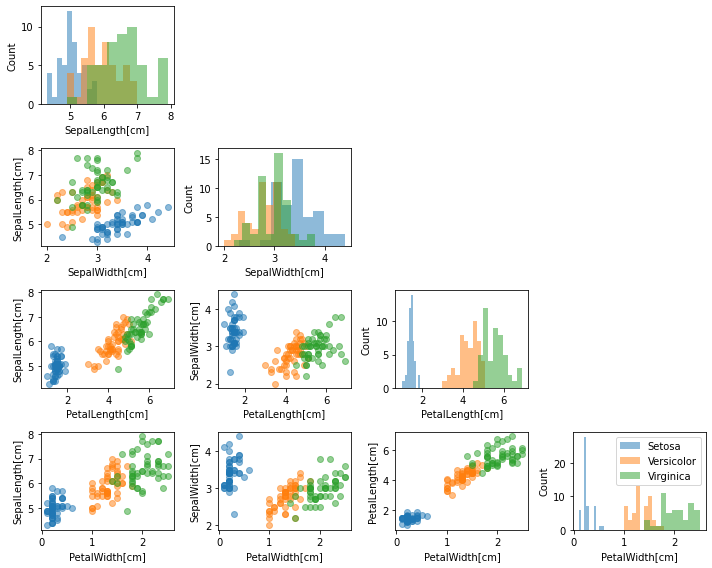

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from mlxtend.data import iris_data
from mlxtend.plotting import scatterplotmatrix


names = df.columns[1:5]

fig, axes = scatterplotmatrix(X[y==0], figsize=(10, 8), alpha=0.5)
fig, axes = scatterplotmatrix(X[y==1], fig_axes=(fig, axes), alpha=0.5)
fig, axes = scatterplotmatrix(X[y==2], fig_axes=(fig, axes), alpha=0.5, names=names)

plt.tight_layout()
plt.legend(labels=['Setosa', 'Versicolor', 'Virginica'])
#plt.savefig('images/eda.pdf')
plt.show()

**Dataset (Train, Validation, Test)**

In [13]:
import numpy as np

indices = np.arange(X.shape[0])
rng = np.random.RandomState(123)
permuted_indices = rng.permutation(indices)
permuted_indices

array([ 72, 112, 132,  88,  37, 138,  87,  42,   8,  90, 141,  33,  59,
       116, 135, 104,  36,  13,  63,  45,  28, 133,  24, 127,  46,  20,
        31, 121, 117,   4, 130, 119,  29,   0,  62,  93, 131,   5,  16,
        82,  60,  35, 143, 145, 142, 114, 136,  53,  19,  38, 110,  23,
         9,  86,  91,  89,  79, 101,  65, 115,  41, 124,  95,  21,  11,
       103,  74, 122, 118,  44,  51,  81, 149,  12, 129,  56,  50,  25,
       128, 146,  43,   1,  71,  54, 100,  14,   6,  80,  26,  70, 139,
        30, 108,  15,  18,  77,  22,  10,  58, 107,  75,  64,  69,   3,
        40,  76, 134,  34,  27,  94,  85,  97, 102,  52,  92,  99, 105,
         7,  48,  61, 120, 137, 125, 147,  39,  84,   2,  67,  55,  49,
        68, 140,  78, 144, 111,  32,  73,  47, 148, 113,  96,  57, 123,
       106,  83,  17,  98,  66, 126, 109])

In [14]:
train_size, valid_size = int(0.65*X.shape[0]), int(0.15*X.shape[0])
test_size = X.shape[0] - (train_size + valid_size)
print(train_size, valid_size, test_size)

97 22 31


In [15]:
train_ind = permuted_indices[:train_size]
valid_ind = permuted_indices[train_size:(train_size + valid_size)]
test_ind = permuted_indices[(train_size + valid_size):]

In [16]:
X_train, y_train = X[train_ind], y[train_ind]
X_valid, y_valid = X[valid_ind], y[valid_ind]
X_test, y_test = X[test_ind], y[test_ind]

X_train.shape

(97, 4)

**Python Classes**

In [17]:
class VehicleClass():
  def __init__(self, horsepower):
    self.horsepower = horsepower

  def horsepower_to_torque(self, rpm):
    numerator = self.horsepower * 33000
    denominator = 2 * np.pi * 5000
    return numerator/denominator

  def tune_motor(self):
    self.horsepower *= 2

  def _private_method(self):
    print('This is private')

  def __very_private_method(self):
    print('This is very private')

In [18]:
car1 = VehicleClass(horsepower=123)
print(car1.horsepower)

123


In [19]:
car1.horsepower_to_torque(rpm=5000)

129.20198280200063

In [20]:
car1.tune_motor()
car1.horsepower_to_torque(rpm=5000)

258.40396560400126

In [21]:
car1._private_method()

This is private


In [22]:
car1._VehicleClass__very_private_method()

This is very private


In [23]:
class CarClass(VehicleClass):
  def __init__(self, horsepower):
    super(CarClass, self).__init__(horsepower)
    self.num_wheels = 4

new_car = CarClass(horsepower=123)
print('Number of wheels:', new_car.num_wheels)
print('Horsepower:', new_car.horsepower)
new_car.tune_motor()
print('Horsepower:', new_car.horsepower)

Number of wheels: 4
Horsepower: 123
Horsepower: 246


**KNN Implementation**

In [27]:
class KNNClassifier(object):
    def __init__(self, k, dist_fn=None):
        self.k = k
        if dist_fn is None:
            self.dist_fn = self._euclidean_dist
    
    def _euclidean_dist(self, a, b):
        dist = 0.
        for ele_i, ele_j in zip(a, b):
            dist += ((ele_i - ele_j)**2)
        dist = dist**0.5
        return dist
        
    def _find_nearest(self, x):
        dist_idx_pairs = []
        for j in range(self.dataset_.shape[0]):
            d = self.dist_fn(x, self.dataset_[j])
            dist_idx_pairs.append((d, j))
            
        sorted_dist_idx_pairs = sorted(dist_idx_pairs)

        return sorted_dist_idx_pairs
    
    def fit(self, X, y):
        self.dataset_ = X.copy()
        self.labels_ = y.copy()
        self.possible_labels_ = np.unique(y)

    def predict(self, X):
        predictions = np.zeros(X.shape[0], dtype=int)
        for i in range(X.shape[0]):
            k_nearest = self._find_nearest(X[i])[:self.k]
            indices = [entry[1] for entry in k_nearest]
            k_labels = self.labels_[indices]
            counts = np.bincount(k_labels,
                                 minlength=self.possible_labels_.shape[0])
            pred_label = np.argmax(counts)
            predictions[i] = pred_label
        return predictions
    
knn_model = KNNClassifier(k=3)
knn_model.fit(X_train, y_train)

In [28]:
print(knn_model.predict(X_valid))

[0 1 2 1 1 1 0 0 1 2 0 0 1 1 1 2 1 1 1 2 0 0]


**Stratification**

In [32]:
from sklearn.model_selection import train_test_split


X_temp, X_test, y_temp, y_test = \
        train_test_split(X, y, test_size=0.2, 
                         shuffle=True, random_state=123, stratify=y)
print(np.bincount(y_temp))
print(X_train.shape)

[40 40 40]
(96, 4)


In [33]:
X_train, X_valid, y_train, y_valid = \
        train_test_split(X_temp, y_temp, test_size=0.2,
                         shuffle=True, random_state=123, stratify=y_temp)

print('Train size', X_train.shape, 'class proportions', np.bincount(y_train))
print('Valid size', X_valid.shape, 'class proportions', np.bincount(y_valid))
print('Test size', X_test.shape, 'class proportions', np.bincount(y_test))

Train size (96, 4) class proportions [32 32 32]
Valid size (24, 4) class proportions [8 8 8]
Test size (30, 4) class proportions [10 10 10]


**Normalization: min-max scaling**

In [34]:
x = np.arange(6).astype(float)
x

array([0., 1., 2., 3., 4., 5.])

In [35]:
x_norm = (x - x.min()) / (x.max() - x.min())
x_norm

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

**Normalization: standardization**

In [36]:
x = np.arange(6).astype(float)
x

array([0., 1., 2., 3., 4., 5.])

In [37]:
x_std = (x - x.mean()) / x.std()
x_std

array([-1.46385011, -0.87831007, -0.29277002,  0.29277002,  0.87831007,
        1.46385011])

In [38]:
df = pd.DataFrame([1, 2, 1, 2, 3, 4])
df[0].std()

1.1690451944500122

In [39]:
df[0].values.std()

1.0671873729054748

In [40]:
df[0].values.std(ddof=1)

1.1690451944500122

In [41]:
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)

X_train_std = (X_train - mu) / sigma
X_valid_std = (X_valid - mu) / sigma
X_test_std = (X_test - mu) / sigma

**Scikit-Learn Transformer**

In [42]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_std = scaler.transform(X_train)
X_valid_std = scaler.transform(X_valid)
X_test_std = scaler.transform(X_test)

In [43]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine_learning_utfpr/preprocessing/categoricaldata.csv')
df

,color,size,price,classlabel
0,green,M,10.1,class1
1,red,L,13.5,class2
2,blue,XXL,15.3,class1


In [44]:
mapping_dict = {'M': 2,
                'L': 3,
                'XXL': 5}

df['size'] = df['size'].map(mapping_dict)
df

,color,size,price,classlabel
0,green,2,10.1,class1
1,red,3,13.5,class2
2,blue,5,15.3,class1


In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['classlabel'] = le.fit_transform(df['classlabel'])
df

,color,size,price,classlabel
0,green,2,10.1,0
1,red,3,13.5,1
2,blue,5,15.3,0


In [46]:
pd.get_dummies(df)

,size,price,classlabel,color_blue,color_green,color_red
0,2,10.1,0,0,1,0
1,3,13.5,1,0,0,1
2,5,15.3,0,1,0,0


In [47]:
pd.get_dummies(df, drop_first=True)

,size,price,classlabel,color_green,color_red
0,2,10.1,0,1,0
1,3,13.5,1,0,1
2,5,15.3,0,0,0


In [48]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine_learning_utfpr/preprocessing/missingdata.csv')
df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,NaN,8.0
2,10.0,11.0,12.0,NaN


In [49]:
df.isnull().sum()

A    0
B    0
C    1
D    1
dtype: int64

In [50]:
df.dropna(axis=0)

,A,B,C,D
0,1.0,2.0,3.0,4.0


In [51]:
df.dropna(axis=1)

,A,B
0,1.0,2.0
1,5.0,6.0
2,10.0,11.0


In [52]:
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X = df.values
X = imputer.fit_transform(df.values)
X

array([[ 1. ,  2. ,  3. ,  4. ],
       [ 5. ,  6. ,  7.5,  8. ],
       [10. , 11. , 12. ,  6. ]])